In [1]:
from google.colab import files
uploaded = files.upload()

Saving pubmedqa_cleaned.csv to pubmedqa_cleaned.csv


In [4]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
df = pd.read_csv("/content/pubmedqa_cleaned.csv")
df.head()

,question,context,answer
0,is naturopathy as effective as conventional therapy for treatment of menopausal symptoms,although the use of alternative medicine in the united states is increasing no published studies have documented the effectiveness of naturopathy for treatment of menopausal symptoms compared to women receiving conventional therapy in the clinical setting to compare naturopathic therapy with conventional medical therapy for treatment of selected menopausal symptoms a retrospective cohort study using abstracted data from medical charts one natural medicine and six conventional medical clinics at community health centers of king county washington from november 1 1996 through july 31 1998 women aged 40 years of age or more with a diagnosis of menopausal symptoms documented by a naturopathic or conventional physician improvement in selected menopausal symptoms in univariate analyses patients treated with naturopathy for menopausal symptoms reported higher monthly incomes 1848 00 versus 853 60 were less likely to be smokers 11 4 versus 41 9 exercised more frequently and reported higher frequencies of decreased energy 41 8 versus 24 4 insomnia 57 0 versus 33 1 and hot flashes 69 6 versus 55 6 at baseline than those who received conventional treatment in multivariate analyses patients treated with naturopathy were approximately seven times more likely than conventionally treated patients to report improvement for insomnia odds ratio or 6 77 95 confidence interval ci 1 71 26 63 and decreased energy or 6 55 95 ci 0 96 44 74 naturopathy patients reported improvement for anxiety or 1 27 95 ci 0 63 2 56 hot flashes or 1 40 95 ci 0 68 2 88 menstrual changes or 0 98 95 ci 0 43 2 24 and vaginal dryness or 0 91 95 ci 0 21 3 96 about as frequently as patients who were treated conventionally,naturopathy appears to be an effective alternative for relief of specific menopausal symptoms compared to conventional therapy
1,can randomised trials rely on existing electronic data,to estimate the feasibility utility and resource implications of electronically captured routine data for health technology assessment by randomised controlled trials rcts and to recommend how routinely collected data could be made more effective for this purpose four health technology assessments that involved patients under care at five district general hospitals in the uk using four conditions from distinct classical specialties inflammatory bowel disease obstructive sleep apnoea female urinary incontinence and total knee replacement patient identifiable electronically stored routine data were sought from the administration and clinical database to provide the routine data four rcts were replicated using routine data in place of the data already collected for the specific purpose of the assessments this was done by modelling the research process from conception to final writing up and substituting routine for designed data activities at appropriate points this allowed a direct comparison to be made of the costs and outcomes of the two approaches to health technology assessment the trial designs were a two centre randomised trial of outpatient follow up a single centre randomised trial of two investigation techniques a three centre randomised trial of two surgical operations and a single centre randomised trial of perioperative anaesthetic intervention generally two thirds of the research questions posed by health technology assessment through rcts could be answered using routinely collected data where these questions required analysis of nhs resource use data could usually be identified clinical effectiveness could also be judged using proxy measures for quality of life provided clinical symptoms and signs were collected in sufficient detail patient and professional preferences could not be identified from routine data but could be collected routinely by adapting existing instruments routine data were found potentially to be cheaper to extract and analyse than

In [16]:
keywords = {
    'Treatment': ['surgery', 'operation', 'repair', 'procedure'],
    'Medication': ['drug', 'medication', 'antidepressant', 'therapy'],
    'Symptoms': ['symptom', 'sign', 'manifestation', 'impairment'],
    'Diagnosis': ['diagnosis', 'imaging', 'classification', 'biopsy'],
    'Prevention': ['prevention', 'avoid', 'vaccination', 'prophylaxis']
}

In [18]:
def label_row(row):
    text = (str(row['question']) + " " + str(row['context'])).lower()
    for label, words in keywords.items():
        if any(word in text for word in words):
            return label
    return 'General'

In [20]:
df['label'] = df.apply(label_row, axis=1)
df.head(10)

,question,context,answer,category,label
0,is naturopathy as effective as conventional therapy for treatment of menopausal symptoms,although the use of alternative medicine in the united states is increasing no published studies have documented the effectiveness of naturopathy for treatment of menopausal symptoms compared to women receiving conventional therapy in the clinical setting to compare naturopathic therapy with conventional medical therapy for treatment of selected menopausal symptoms a retrospective cohort study using abstracted data from medical charts one natural medicine and six conventional medical clinics at community health centers of king county washington from november 1 1996 through july 31 1998 women aged 40 years of age or more with a diagnosis of menopausal symptoms documented by a naturopathic or conventional physician improvement in selected menopausal symptoms in univariate analyses patients treated with naturopathy for menopausal symptoms reported higher monthly incomes 1848 00 versus 853 60 were less likely to be smokers 11 4 versus 41 9 exercised more frequently and reported higher frequencies of decreased energy 41 8 versus 24 4 insomnia 57 0 versus 33 1 and hot flashes 69 6 versus 55 6 at baseline than those who received conventional treatment in multivariate analyses patients treated with naturopathy were approximately seven times more likely than conventionally treated patients to report improvement for insomnia odds ratio or 6 77 95 confidence interval ci 1 71 26 63 and decreased energy or 6 55 95 ci 0 96 44 74 naturopathy patients reported improvement for anxiety or 1 27 95 ci 0 63 2 56 hot flashes or 1 40 95 ci 0 68 2 88 menstrual changes or 0 98 95 ci 0 43 2 24 and vaginal dryness or 0 91 95 ci 0 21 3 96 about as frequently as patients who were treated conventionally,naturopathy appears to be an effective alternative for relief of specific menopausal symptoms compared to conventional therapy,Treatment,Medication
1,can randomised trials rely on existing electronic data,to estimate the feasibility utility and resource implications of electronically captured routine data for health technology assessment by randomised controlled trials rcts and to recommend how routinely collected data could be made more effective for this purpose four health technology assessments that involved patients under care at five district general hospitals in the uk using four conditions from distinct classical specialties inflammatory bowel disease obstructive sleep apnoea female urinary incontinence and total knee replacement patient identifiable electronically stored routine data were sought from the administration and clinical database to provide the routine data four rcts were replicated using routine data in place of the data already collected for the specific purpose of the assessments this was done by modelling the research process from conception to final writing up and substituting routine for designed data activities at appropriate points this allowed a direct comparison to be made of the costs and outcomes of the two approaches to health technology assessment the trial designs were a two centre randomised trial of outpatient follow up a single centre randomised trial of two investigation techniques a three centre randomised trial of two surgical operations and a single centre randomised trial of perioperative anaesthetic intervention generally two thirds of the research questions posed by health technology assessment through rcts could be answered using routinely collected data where these questions required analysis of nhs resource use data could usually be identified clinical effectiveness could also be judged using proxy measures for quality of life provided clinical symptoms and signs were collected in sufficient detail patient and professional preferences could not be identified from routine data but could be collected routinely by adapting existing instruments routine data were found potentially to be

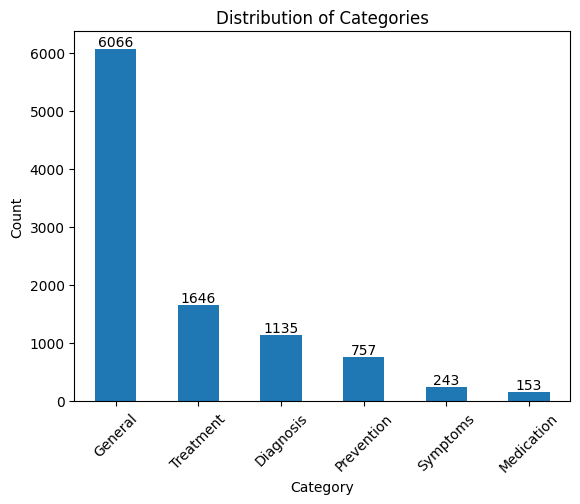

In [22]:
import matplotlib.pyplot as plt

category_counts = df["category"].value_counts().sort_values(ascending=False)

plt.figure()
ax = category_counts.plot(kind='bar')

for i, v in enumerate(category_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

In [24]:
from google.colab import files
df.to_csv("/content/labeled_dataset.csv", index=False)
files.download("/content/labeled_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>